In [148]:
from langchain_groq import ChatGroq

In [149]:
llm=ChatGroq(
    model_name="deepseek-r1-distill-llama-70b",
    temperature=0,
)
response = llm.invoke("What is the capital of France?")

In [150]:
response.content

'<think>\n\n</think>\n\nThe capital of France is Paris.'

In [151]:
from langchain.tools import tool

Custom tools

In [152]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers.
Args:
    a (int): The first number.
    b (int): The second number.
Returns:
    int: The product of a and b.
"""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds two numbers.
    Args:
        a (int): The first number.
        b (int): The second number.
    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divides a by b.
    Args:
        a (int): The numerator.
        b (int): The denominator.
    Returns:
        float: The result of the division.
    """     
    if b == 0:
        raise ValueError("Division by zero is not allowed.")
    return a / b


In [153]:
from langchain_community.tools import DuckDuckGoSearchRun

In [154]:
search = DuckDuckGoSearchRun()

In [155]:
search.invoke("iPhone 17 release date")

c:\Swdtools\conda_envs\py311_agenticai\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


'No good DuckDuckGo Search Result was found'

In [156]:
tools = [multiply, add, divide, search]

In [157]:
llm_with_tools = llm.bind_tools(tools)

In [158]:
response = llm_with_tools.invoke("Hii")
response

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'Alright, the user sent "Hii". That\'s a friendly greeting, but not a specific question or task. I should respond in a way that\'s welcoming and offers assistance. Maybe ask how I can help them today. Keeping it open-ended encourages them to provide more details about what they need.\n'}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 388, 'total_tokens': 462, 'completion_time': 0.400887243, 'prompt_time': 0.044038816, 'queue_time': 0.049609154, 'total_time': 0.444926059}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--554ed333-b00c-44ad-a35d-e110fa5e78ce-0', usage_metadata={'input_tokens': 388, 'output_tokens': 74, 'total_tokens': 462})

In [159]:
response = llm_with_tools.invoke("what is 2+2? ")
response


AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, so the user is asking, "what is 2+2?" That\'s a pretty straightforward math problem. I remember that I have access to a tool called "add" which can add two numbers. Let me check the function details again to make sure I use it correctly.\n\nThe "add" function takes two parameters, both integers, and returns their sum. So, I need to pass 2 as the first argument and 2 as the second argument. That should give me the correct result.\n\nI should format the tool call properly. The function name is "add", and the arguments should be a JSON object with "a" set to 2 and "b" set to 2. Let me make sure the syntax is correct so that the system can process it without any issues.\n\nAlright, I think that\'s all I need to do. Once I send this, the tool should return 4 as the result.\n', 'tool_calls': [{'id': 'rnjfgvm38', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage

In [160]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END,MessagesState


In [161]:
builder = StateGraph(MessagesState)

In [162]:
user_query = ["tell me what is 2+2"]

In [163]:
SYSTEM_PROMPT= "you are a helpful assistant with using search and performing arithmetic on a set of inputs."
[SYSTEM_PROMPT]+ user_query

['you are a helpful assistant with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [164]:
def function_1(state: MessagesState) -> MessagesState:
    user_question = state["messages"]
    input_question = [SYSTEM_PROMPT]+ user_question
    response = llm_with_tools.invoke(input_question)
    return {"messages":[response]}

In [165]:
builder.add_node("llm_decision_step", function_1)

In [166]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))


In [167]:
builder.add_edge(START, "llm_decision_step")

In [168]:
from langgraph.prebuilt import tools_condition


builder.add_conditional_edges("llm_decision_step",
                              tools_condition)

In [169]:
builder.add_edge("tools", "llm_decision_step")

In [170]:
react_graph = builder.compile()

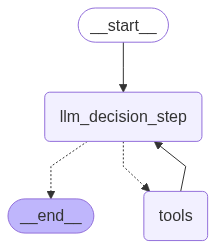

In [171]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [172]:

message= [HumanMessage(content="what is 2 times the age of Elon Musk")]

In [173]:
respose = react_graph.invoke({"messages":message})

c:\Swdtools\conda_envs\py311_agenticai\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


In [174]:
response["messages"][-1].content

TypeError: 'AIMessage' object is not subscriptable